In [8]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
from algos.naive import naive_search
from algos.rabin_karp import rabin_karp_search, vectorized_rabin_karp
from algos.greedy import greedy_kmp_search, greedy_bm_search

def get_hollow_pattern(size):
    p = np.zeros((size, size), dtype=int)
    p[0, :] = 1; p[-1, :] = 1; p[:, 0] = 1; p[:, -1] = 1
    return p

def run_suite():
    # KEEPING YOUR ORIGINAL DIMENSIONS
    dims = [50, 100, 200, 300, 400, 500, 1000] 
    p_sizes = [3, 5, 7]
    seeds = [42, 62, 82, 12, 24, 2] # Multiple seeds for random case averaging
    
    algos = [
        ("Naive", naive_search),
        ("Rabin-Karp", rabin_karp_search),
        ("Vectorized Rabin-Karp", vectorized_rabin_karp),
        ("Greedy KMP", greedy_kmp_search),
        ("Greedy BM", greedy_bm_search)
    ]
    
    results = []
    
    # 1. Random Tests (Averaged over seeds)
    for dim in dims:
        for ps in p_sizes:
            pattern = get_hollow_pattern(ps)
            
            # Temporary storage to average seeds for this specific (dim, ps, algo)
            seed_results = {name: {"comps": [], "times": []} for name, _ in algos}
            
            for s in seeds:
                np.random.seed(s)
                text = np.random.randint(2, size=(dim, dim))
                
                for name, func in algos:
                    start = time.perf_counter()
                    count, pos = func(text, pattern)
                    elapsed = time.perf_counter() - start
                    seed_results[name]["comps"].append(count)
                    seed_results[name]["times"].append(elapsed)
            
            # Record averaged results
            for name, _ in algos:
                results.append({
                    "dim": dim, 
                    "p_size": ps, 
                    "algo": name, 
                    "type": "Random", 
                    "comparisons": np.mean(seed_results[name]["comps"]), 
                    "time": np.mean(seed_results[name]["times"])
                })
                
    # 2. Contrived "Trigger" Tests
    for dim in dims:
        for ps in p_sizes:
            text = np.zeros((dim, dim), dtype=int)
            pattern = get_hollow_pattern(ps)
            text[:, :ps] = pattern[0]
            text[-ps:, -ps:] = pattern
            
            for name, func in algos:
                start = time.perf_counter()
                count, pos = func(text, pattern)
                elapsed = time.perf_counter() - start
                results.append({
                    "dim": dim, 
                    "p_size": ps, 
                    "algo": name, 
                    "type": "Trigger", 
                    "comparisons": count, 
                    "time": elapsed
                })

    return pd.DataFrame(results)

df = run_suite()
df.to_csv("benchmark_results.csv", index=False) # SAVING CSV AS REQUESTED

# --- 3. Visualizations (Updated for Time and Comparisons) ---

def plot_results(df):
    types = df['type'].unique()
    p_sizes = df['p_size'].unique()
    
    for t in types:
        for ps in p_sizes:
            subset = df[(df['type'] == t) & (df['p_size'] == ps)]
            
            # Create two subplots: one for comparisons, one for wall-clock time
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            for algo in subset['algo'].unique():
                algo_data = subset[subset['algo'] == algo]
                ax1.plot(algo_data['dim'], algo_data['comparisons'], marker='o', label=algo)
                ax2.plot(algo_data['dim'], algo_data['time'], marker='s', label=algo)
            
            ax1.set_title(f"Comparisons: {t} Case (Pattern {ps}x{ps})")
            ax1.set_xlabel("Dimension")
            ax1.set_ylabel("Count")
            ax1.legend()
            ax1.grid(True)

            ax2.set_title(f"Wallclock Time: {t} Case (Pattern {ps}x{ps})")
            ax2.set_xlabel("Dimension")
            ax2.set_ylabel("Seconds")
            ax2.set_yscale('log') # Useful for seeing Vectorized vs Loop
            ax2.legend()
            ax2.grid(True)
            
            plt.tight_layout()
            plt.savefig(f"bench_{t}_p{ps}.png")
            plt.close()

plot_results(df)

c:\Users\Joel Ethan Batac\Documents\csc755m\master_searcher\algos\rabin_karp.py:24: RuntimeWarning: overflow encountered in scalar multiply
  p_hash = (p_hash * X_BASE + row_h) % MOD
c:\Users\Joel Ethan Batac\Documents\csc755m\master_searcher\algos\rabin_karp.py:45: RuntimeWarning: overflow encountered in scalar multiply
  curr_v_h = (curr_v_h * X_BASE + row_hashes[i, j]) % MOD
c:\Users\Joel Ethan Batac\Documents\csc755m\master_searcher\algos\rabin_karp.py:47: RuntimeWarning: overflow encountered in scalar multiply
  curr_v_h = (curr_v_h - row_hashes[i - p_height, j] * x_pow) % MOD
c:\Users\Joel Ethan Batac\Documents\csc755m\master_searcher\algos\rabin_karp.py:47: RuntimeWarning: overflow encountered in scalar subtract
  curr_v_h = (curr_v_h - row_hashes[i - p_height, j] * x_pow) % MOD
c:\Users\Joel Ethan Batac\Documents\csc755m\master_searcher\algos\rabin_karp.py:45: RuntimeWarning: overflow encountered in scalar add
  curr_v_h = (curr_v_h * X_BASE + row_hashes[i, j]) % MOD
c:\Users\J

KeyboardInterrupt: 

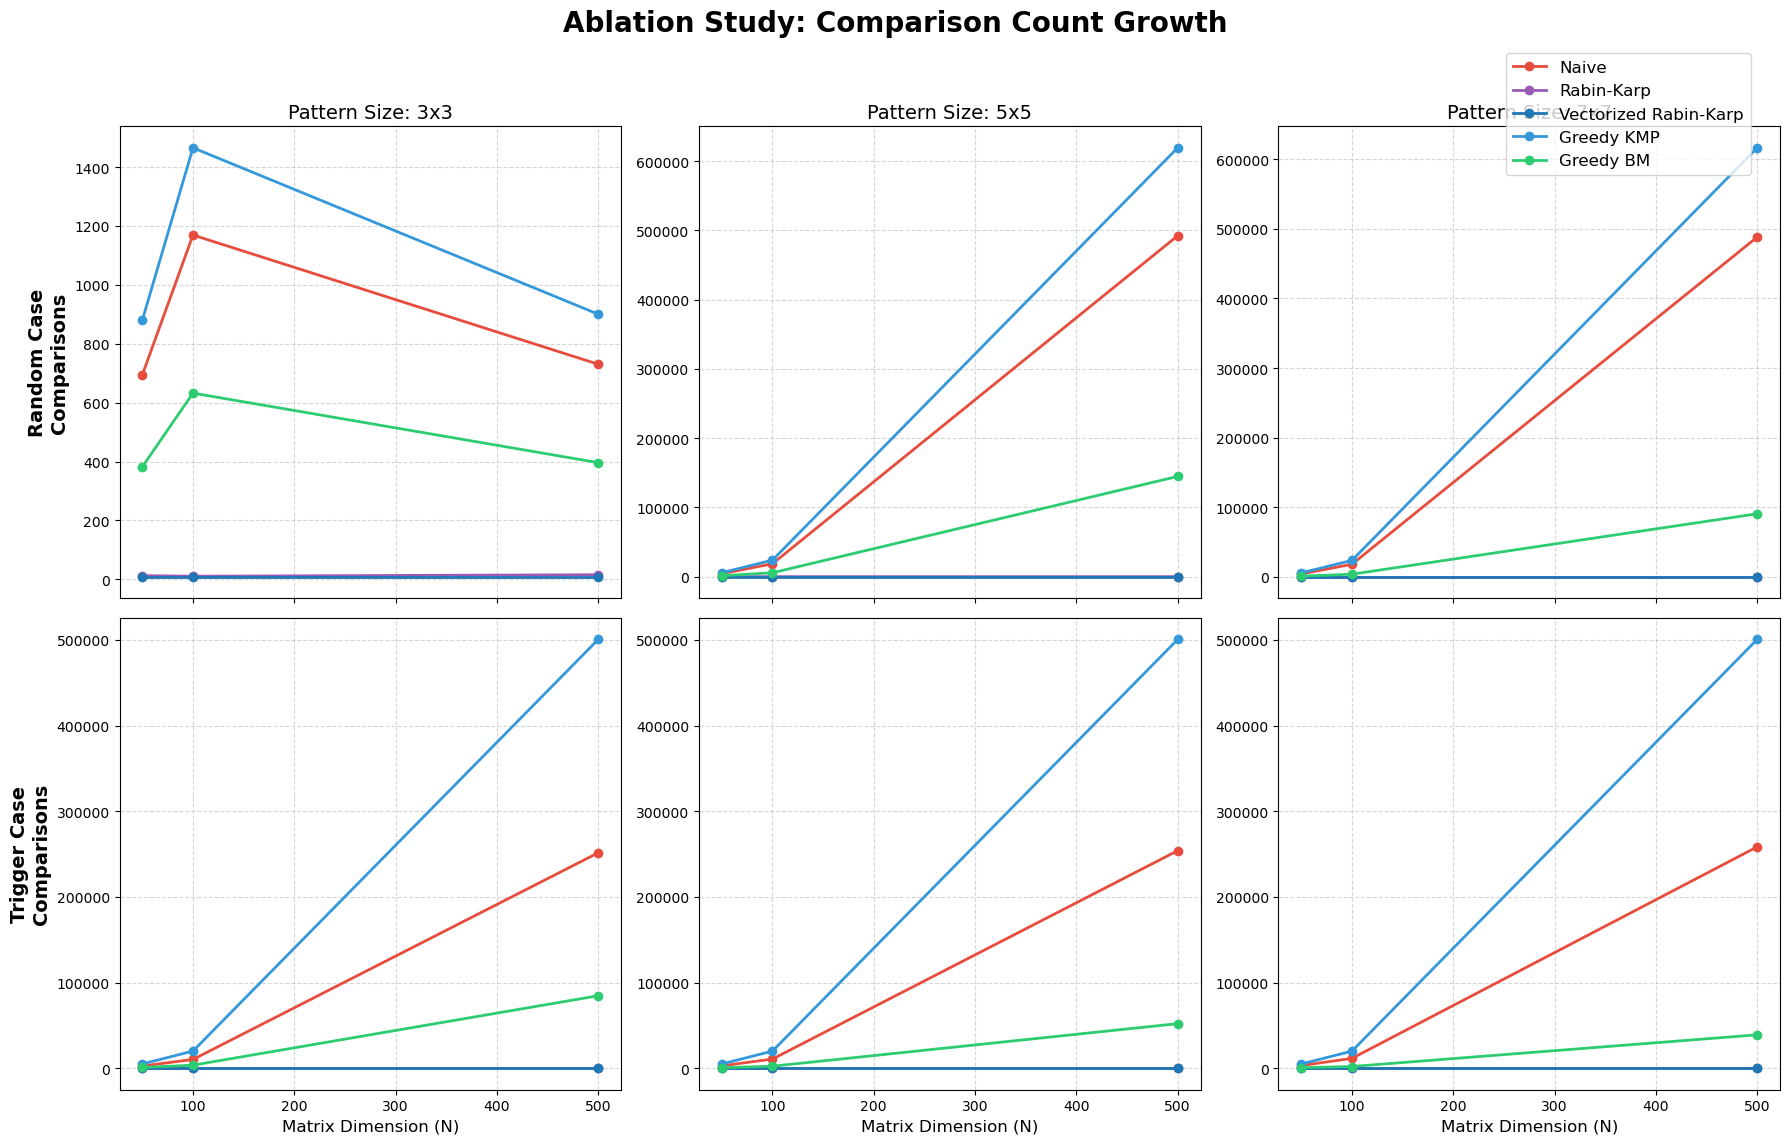

In [ ]:
# Load the data generated in the previous step
df = pd.read_csv("benchmark_results.csv")

# Create a multi-panel figure
# We will create 2 rows (Random vs Trigger) and 3 columns (Pattern sizes 3, 5, 7)
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
fig.suptitle('Ablation Study: Comparison Count Growth', fontsize=20, fontweight='bold')

test_types = ['Random', 'Trigger']
p_sizes = [3, 5, 7]
colors = {'Naive': '#e74c3c', 'Rabin-Karp': '#9b59b6', 'Greedy KMP': '#3498db', 'Greedy BM': '#2ecc71'}

for i, t_type in enumerate(test_types):
    for j, p_size in enumerate(p_sizes):
        ax = axes[i, j]
        subset = df[(df['type'] == t_type) & (df['p_size'] == p_size)]
        
        for algo in subset['algo'].unique():
            algo_data = subset[subset['algo'] == algo]
            ax.plot(algo_data['dim'], algo_data['comparisons'], 
                    marker='o', label=algo, color=colors.get(algo, None), linewidth=2)
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
        if i == 0:
            ax.set_title(f'Pattern Size: {p_size}x{p_size}', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'{t_type} Case\nComparisons', fontsize=14, fontweight='bold')
        if i == 1:
            ax.set_xlabel('Matrix Dimension (N)', fontsize=12)

# Add a single legend for the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95), fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('unified_results.png')
plt.show()


In [ ]:
# Load the data generated in the previous step
df = pd.read_csv("benchmark_results.csv")

# Create a multi-panel figure
# We will create 2 rows (Random vs Trigger) and 3 columns (Pattern sizes 3, 5, 7)
fig, axes = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
fig.suptitle('Ablation Study: Comparison Count Growth', fontsize=20, fontweight='bold')

test_types = ['Random', 'Trigger']
p_sizes = [3, 5, 7]
colors = {'Naive': '#e74c3c', 'Rabin-Karp': '#9b59b6', 'Greedy KMP': '#3498db', 'Greedy BM': '#2ecc71'}

for i, t_type in enumerate(test_types):
    for j, p_size in enumerate(p_sizes):
        ax = axes[i, j]
        subset = df[(df['type'] == t_type) & (df['p_size'] == p_size)]
        
        for algo in subset['algo'].unique():
            algo_data = subset[subset['algo'] == algo]
            ax.plot(algo_data['dim'], algo_data['time'], 
                    marker='o', label=algo, color=colors.get(algo, None), linewidth=2)
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
        if i == 0:
            ax.set_title(f'Pattern Size: {p_size}x{p_size}', fontsize=14)
        if j == 0:
            ax.set_ylabel(f'{t_type} Case\nComparisons', fontsize=14, fontweight='bold')
        if i == 1:
            ax.set_xlabel('Matrix Dimension (N)', fontsize=12)

# Add a single legend for the whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.95), fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
from algos.naive import naive_search
from algos.rabin_karp import vectorized_rabin_karp, rabin_karp_search
from algos.bird import bird_bm, bird_kmp
from algos.greedy import greedy_bm_search, greedy_kmp_search
import numpy as np

In [ ]:
text = np.random.randint(2, size=(10000, 10000))
pattern = np.array([[1, 0, 0, 1, 1],
                   [1, 0, 1, 0, 1],
                   [1, 1, 0, 0, 1],
                  [1, 1, 1, 1, 1]])

In [ ]:
res = bird_bm(text, pattern)
res

(1187021, (480, 3711))

In [ ]:
res2 = bird_kmp(text, pattern)
res2

(5104051, (480, 3711))

In [ ]:
res3 = greedy_bm_search(text, pattern)
res3

(7133278, (480, 3711))

In [ ]:
res3 = greedy_kmp_search(text, pattern)
res3

(9907561, (480, 3711))

In [ ]:
res4 = naive_search(text, pattern)
res4

(9605196, (480, 3711))

In [ ]:
text[15:, 35:]

array([[0, 1, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 1, 0, 1],
       [1, 0, 1, ..., 0, 1, 1],
       ...,
       [0, 1, 1, ..., 1, 1, 0],
       [0, 1, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 0, 1]])